# EDA Indicateur 0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv(r"./raw/dvf.csv")
df.head(10)

C:\Users\pasca\AppData\Local\Temp\ipykernel_26064\2114903331.py:7: DtypeWarning: Columns (0: code_commune, 1: code_departement, 2: ancien_nom_commune, 3: ancien_id_parcelle, 4: numero_volume, 5: lot1_numero, 6: lot2_numero, 7: lot3_numero, 8: lot4_numero, 9: lot5_numero, 10: code_nature_culture_speciale, 11: nature_culture_speciale) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"./raw/dvf.csv")


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2021-1,2021-01-05,1,Vente,185000.0,5080.0,NaN,CHE DE VOGELAS,0471,1370.0,...,Dépendance,NaN,0.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
1,2021-1,2021-01-05,1,Vente,185000.0,5080.0,NaN,CHE DE VOGELAS,0471,1370.0,...,Maison,97.0,5.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
2,2021-2,2021-01-06,1,Vente,10.0,NaN,NaN,ROUGEMONT,B043,1290.0,...,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,530.0,4.844318,46.224242
3,2021-3,2021-01-04,1,Vente,204332.0,7.0,NaN,ALL DES ECUREUILS,0276,1310.0,...,Maison,88.0,4.0,S,sols,NaN,NaN,866.0,5.157674,46.201035
4,2021-4,2021-01-06,1,Vente,320000.0,87.0,NaN,RTE DE CERTINES,0140,1250.0,...,Dépendance,NaN,0.0,S,sols,NaN,NaN,1426.0,5.273214,46.156320
5,2021-4,2021-01-06,1,Vente,320000.0,87.0,NaN,RTE DE CERTINES,0140,1250.0,...,Maison,168.0,5.0,S,sols,NaN,NaN,1426.0,5.273214,46.156320
6,2021-5,2021-01-04,2,Vente,36.3,NaN,NaN,COMBET MAILLET,B077,1250.0,...,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,121.0,5.462968,46.256257
7,2021-6,2021-01-04,1,Vente,176000.0,210.0,NaN,RUE GEORGE SAND,0820,1000.0,...,Appartement,71.0,3.0,NaN,NaN,NaN,NaN,NaN,5.200093,46.210276
8,2021-6,2021-01-04,1,Vente,176000.0,210.0,NaN,RUE GEORGE SAND,0820,1000.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,5.200093,46.210276
9,2021-7,2021-01-11,2,Vente,400.0,NaN,NaN,PRE BROUILLET,B085,1310.0,...,NaN,NaN,NaN,P,prés,NaN,NaN,460.0,5.115375,46.211715


C:\Users\pasca\AppData\Local\Temp\ipykernel_26064\1366407901.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=comparison.index, y=comparison.values, palette=palette)


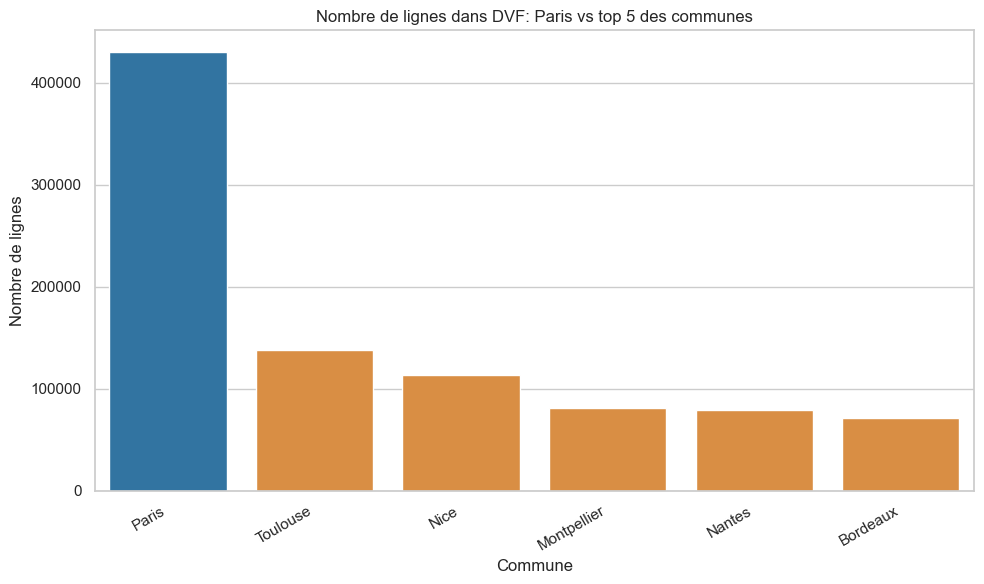

,nombre_de_lignes
Paris,429935
Toulouse,137933
Nice,113505
Montpellier,81361
Nantes,78933
Bordeaux,71276


In [2]:
counts = df['nom_commune'].value_counts()
paris_count = df['code_postal'].astype(str).str.startswith('75').sum()
top5_communes = counts.drop(index='Paris', errors='ignore').head(5)
comparison = pd.concat([pd.Series({'Paris': paris_count}), top5_communes])
comparison = comparison[~comparison.index.duplicated(keep='first')].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
palette = ['#1f77b4' if city == 'Paris' else '#f28e2b' for city in comparison.index]
ax = sns.barplot(x=comparison.index, y=comparison.values, palette=palette)
ax.set_title('Nombre de lignes dans DVF: Paris vs top 5 des communes')
ax.set_xlabel('Commune')
ax.set_ylabel('Nombre de lignes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

comparison.to_frame(name='nombre_de_lignes')